In [81]:
import pandas as pd
#to remove stop words
import nltk
import numpy as np

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import pandas as pd
#to remove stop words
import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")
nltk.download("omw-1.4")
from sklearn.utils import shuffle
from sklearn.feature_extraction.text import TfidfVectorizer
#To divide the dataset into train and test datasets
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
#Train the model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/zanabakbar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/zanabakbar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/zanabakbar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/zanabakbar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/zanabakbar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/zanabakbar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/zanabakbar/nltk_data...
[nltk_data]   Package wordnet is already up-

In [82]:
df_fake = pd.read_csv("Fake.csv")
df_true = pd.read_csv("True.csv")
print(" Fake  Dataset")
print(df_fake.head())
print("True  Dataset ")
print(df_true.head())

 Fake  Dataset
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
True  Dataset 
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...  

In [83]:
#Add a label of either true or false
df_fake["label"]=0
df_true["label"]=1
#Merge the two files 
df=pd.concat([df_fake,df_true], ignore_index=True)

#Shuffle then so they're in a random order
df= shuffle(df,random_state=42).reset_index(drop=True)

print(df.head())
print(f"Merged dataset shape: {df.shape}") #Add a label of either true or false
df_fake["label"]=0
df_true["label"]=1
#Merge the two files 
df=pd.concat([df_fake,df_true], ignore_index=True)

#Shuffle then so they're in a random order
df= shuffle(df,random_state=42).reset_index(drop=True)

print(df.head())
print(f"Merged dataset shape: {df.shape}")

                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  
3         May 22, 2017      0  
4       June 24, 2016       1  
Merged dataset shape: (44898, 5)


In [84]:
df['combined'] = df['title'] + ' ' + df['text']

#Convert it into lowercase for standardization
df["combined"]=df["combined"].str.lower()
print(df.head())

                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  \
0    February 13, 2017      0   
1       April 5, 2017       1   
2  September 27, 2017       1   
3         May 22, 2017      0   
4       June 24, 2016       1   

                                           

In [85]:
cols=['combined','subject','date']
blank=set()
for col in cols:
    for index,text in df[col].items():
         if isinstance(text, str) and text.strip() == "":
            blank.add(index)
df.drop(blank,inplace=True)


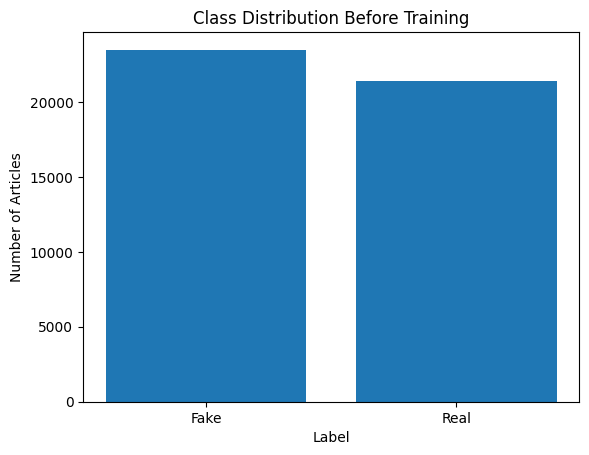

In [86]:
counts = df["label"].value_counts().sort_index()
labels = ["Fake", "Real"]
plt.figure()
plt.bar(labels, counts)
plt.title("Class Distribution Before Training")
plt.xlabel("Label")
plt.ylabel("Number of Articles")
plt.show()

In [87]:
#Remove stopwords

stop_words_nltk=set(stopwords.words("english"))

#Lemmitize the data
#Instantiate the Lemmatizer
l=WordNetLemmatizer()


#A function to tokenize the string

def remove_stop_words_lemmatize(text):
    word= word_tokenize(text)
    filtered= []
    for w in word:
        if w not in stop_words_nltk:
            filtered.append(w)
    lemmas=[l.lemmatize(word)for word in filtered]
    return " ".join(lemmas) 
#Use the stop_word function

for col in cols:
    df[col]=df[col].apply(remove_stop_words_lemmatize)


In [88]:
print(df.head())

                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  \
0   February 13 , 2017      0   
1       April 5 , 2017      1   
2  September 27 , 2017      1   
3        May 22 , 2017      0   
4       June 24 , 2016      1   

                                           

In [89]:
print(df["combined"].head())
print(df["label"].head())

0    ben stein call 9th circuit court : committed ‘...
1    trump drop steve bannon national security coun...
2    puerto rico expects u.s. lift jones act shippi...
3    oops : trump accidentally confirmed leaked isr...
4    donald trump head scotland reopen golf resort ...
Name: combined, dtype: object
0    0
1    1
2    1
3    0
4    1
Name: label, dtype: int64


In [90]:
#Cleaned Dataset
df_clean=df[['combined','subject','date','label']]
df_clean.to_csv("Merged.csv",index=False)


In [91]:
#One code encoding

#To divide the dataset into train and test datasets
#x_train,x_test,y_train

df_train, df_test = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

#TfidVectorize
v_com=TfidfVectorizer(max_features=5)
x_train_comb=v_com.fit_transform(df_train['combined'])
x_test_comb=v_com.transform(df_test['combined'])

#v_sub=TfidfVectorizer()
#x_sub=v_sub.fit_transform(df['subject'])

v_date=TfidfVectorizer(max_features=20)
x_train_date=v_date.fit_transform(df_train['date'])
x_test_date=v_date.transform(df_test['date'])


In [92]:
x_train=hstack([x_train_comb,x_train_date])
x_test=hstack([x_test_comb,x_test_date])

y_train=df_train['label'].values
y_test=df_test['label'].values

In [93]:
print("X_train shape: ", x_train.shape)
print("X_test shape: ", x_test.shape)


X_train shape:  (35918, 25)
X_test shape:  (8980, 25)


In [94]:

#Create an object 
model=LogisticRegression(max_iter=5000,random_state=42)
#Train your model
model.fit(x_train,y_train)

#Predict the values on the test data.
#Returns a 1D array of the same length as x_test. each entry is either 1 or 0
y_pred= model.predict(x_test)


In [95]:
acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
print(f"Accuracy: {acc:.3f}")
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['Fake','Real']))

# %% [markdown]
"""
## Visualizations
Below are plots to interpret model performance and data characteristics.
"""

Accuracy: 0.879
Classification Report:
               precision    recall  f1-score   support

        Fake       0.89      0.88      0.88      4696
        Real       0.87      0.88      0.87      4284

    accuracy                           0.88      8980
   macro avg       0.88      0.88      0.88      8980
weighted avg       0.88      0.88      0.88      8980



'\n## Visualizations\nBelow are plots to interpret model performance and data characteristics.\n'

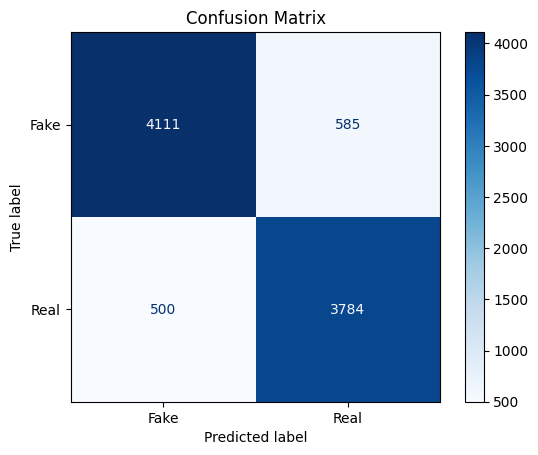

In [96]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Fake','Real'], cmap='Blues'
)
disp.ax_.set_title('Confusion Matrix')
plt.show()

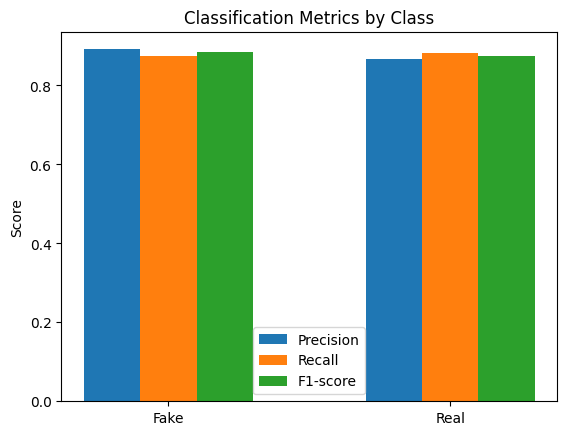

In [97]:
labels = ['Fake','Real']
x = range(len(labels))
width = 0.2

fig, ax = plt.subplots()
ax.bar([i - width for i in x], precision, width, label='Precision')
ax.bar(x, recall, width, label='Recall')
ax.bar([i + width for i in x], f1, width, label='F1-score')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Score')
ax.set_title('Classification Metrics by Class')
ax.legend()
plt.show()


In [99]:
#Compute overall accuracy
#accuracy_score(y_true, y_pred) compares your model’s predictions 
# (y_pred) to the ground-truth  labels (y_test) and calculates:
acc=accuracy_score(y_test, y_pred)
print("******************** CHECK ACCURACY")
print(f"Test-set accuracy: {acc:.3f}")

******************** CHECK ACCURACY
Test-set accuracy: 0.879


In [100]:

#Classification Report
print("\n Classification Report: ")
print(classification_report(y_test,y_pred,target_names=["Fake","Real"]))


 Classification Report: 
              precision    recall  f1-score   support

        Fake       0.89      0.88      0.88      4696
        Real       0.87      0.88      0.87      4284

    accuracy                           0.88      8980
   macro avg       0.88      0.88      0.88      8980
weighted avg       0.88      0.88      0.88      8980



Confusion Matrix
[[4111  585]
 [ 500 3784]]


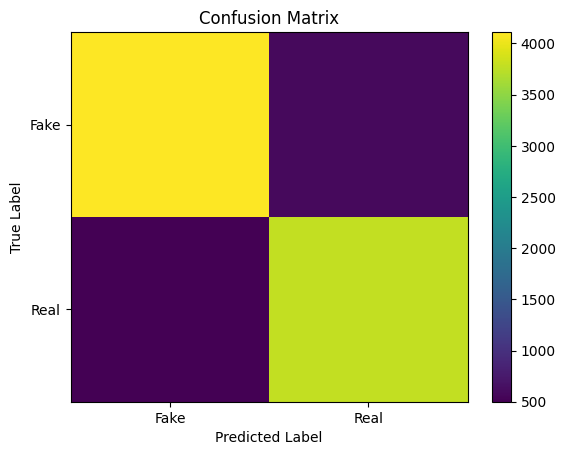

In [101]:

#Confusion Matrix
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm, aspect='auto')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0,1], ["Fake","Real"])
plt.yticks([0,1], ["Fake","Real"])
plt.colorbar()
plt.show()



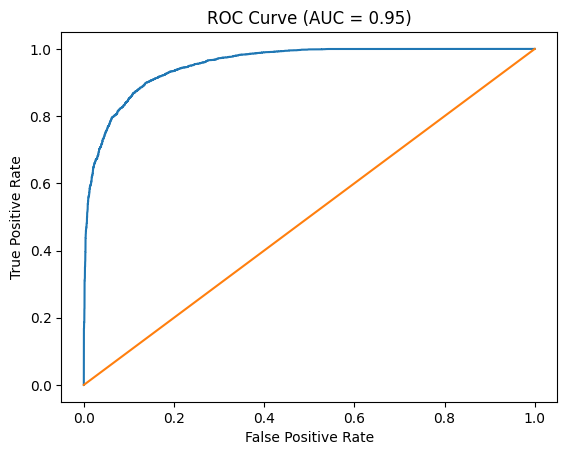

In [102]:
# ROC curve
probs = model.predict_proba(x_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()
